In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

Max folder: 195


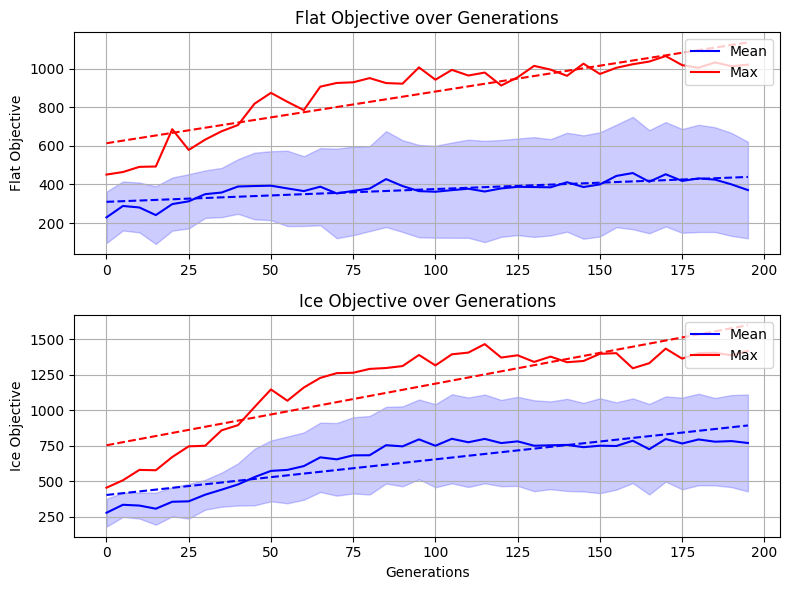

In [18]:
# plot mean and max of both objectives in f over generations. 
# For that read folders with f_best = np.load("results/20260401_113146_nsga_ckpts/i/f.npy") 
# for i in range(0, 600, 10) and plot the mean and max of f on y and generations on x on two subplots.
flat_mean = []
flat_max = []
flat_std = []
ice_mean = []
ice_max = []
ice_std = []


path = "results/20260402_142229_nsga_ckpts"

max_folder = max([int(d) for d in os.listdir(path) if d.isdigit()])
print(f"Max folder: {max_folder}")

fig,axs = plt.subplots(2,1, figsize=(8, 6))
for i in range(0, max_folder+1, 5):
    f = np.load(f"{path}/{i}/f.npy")
    flat_mean.append(np.mean(f, axis=0)[0])
    flat_max.append(np.max(f, axis=0)[0])
    ice_mean.append(np.mean(f, axis=0)[1])
    ice_max.append(np.max(f, axis=0)[1])
    flat_std.append(np.std(f, axis=0)[0])
    ice_std.append(np.std(f, axis=0)[1])

generations = np.arange(0, max_folder+1, 5)

axs[0].plot(generations, flat_mean, label="Mean", color="blue")
axs[0].plot(generations, flat_max, label="Max", color="red")
# add trend lines for both objectives
z = np.polyfit(generations, flat_mean, 1)
p = np.poly1d(z)
axs[0].plot(generations, p(generations), linestyle="--", color="blue")
z = np.polyfit(generations, flat_max, 1)
p = np.poly1d(z)
axs[0].plot(generations, p(generations), linestyle="--", color="red")    
axs[0].set_ylabel("Flat Objective")
axs[0].legend(loc="upper right")
axs[0].fill_between(generations, np.array(flat_mean) - np.array(flat_std), np.array(flat_mean) + np.array(flat_std), alpha=0.2, color="blue")
axs[0].grid("on")
axs[0].set_title("Flat Objective over Generations")


axs[1].plot(generations, ice_mean, label="Mean", color="blue")
axs[1].plot(generations, ice_max, label="Max", color="red")
# add trend lines for both objectives
z = np.polyfit(generations, ice_mean, 1)
p = np.poly1d(z)
axs[1].plot(generations, p(generations), linestyle="--", color="blue")
z = np.polyfit(generations, ice_max, 1)
p = np.poly1d(z)
axs[1].plot(generations, p(generations), linestyle="--", color="red")
axs[1].set_xlabel("Generations")
axs[1].set_ylabel("Ice Objective")
axs[1].legend(loc="upper right")
axs[1].grid("on")

# plot the std of both objectives in f over generations around the mean as a shaded area
axs[1].fill_between(generations, np.array(ice_mean) - np.array(ice_std), np.array(ice_mean) + np.array(ice_std), alpha=0.2, color="blue")
axs[1].set_title("Ice Objective over Generations")

fig.tight_layout()
